# Task NO 1

BFS

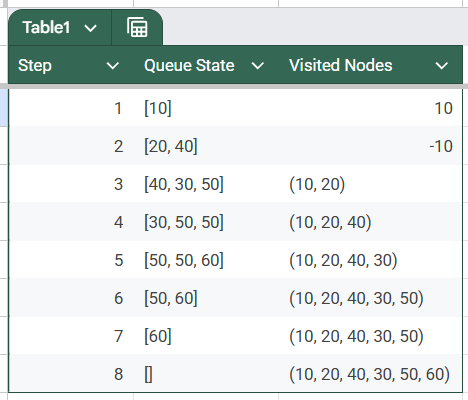

Final BFS Order: 10 → 20 → 40 → 30 → 50 → **60**

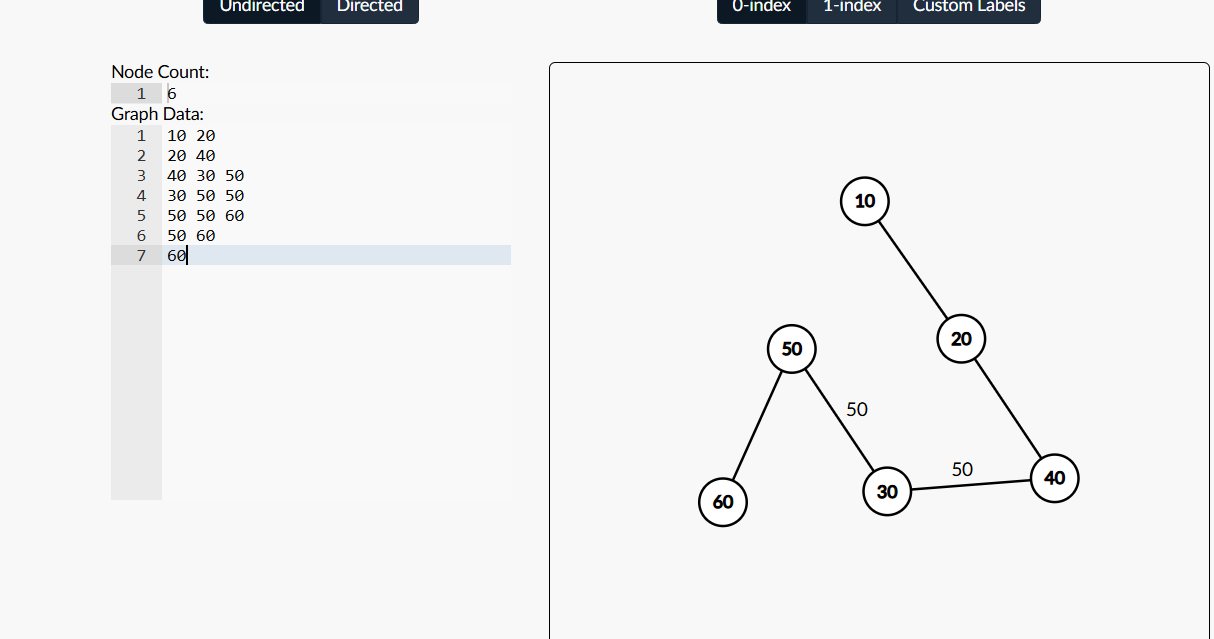

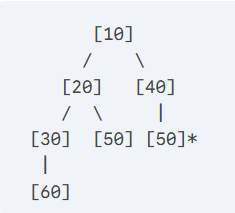

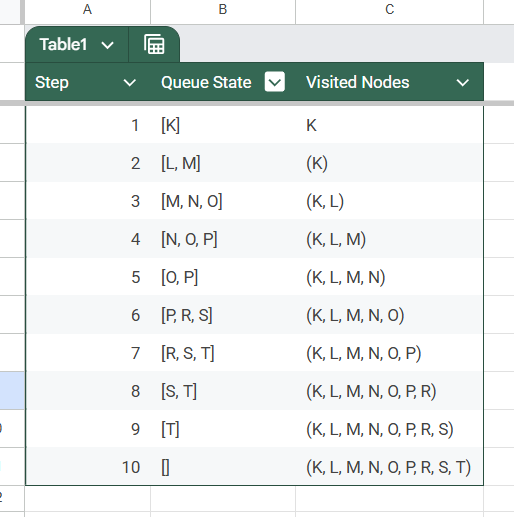

Final BFS Order: K L M N O P R S **T**

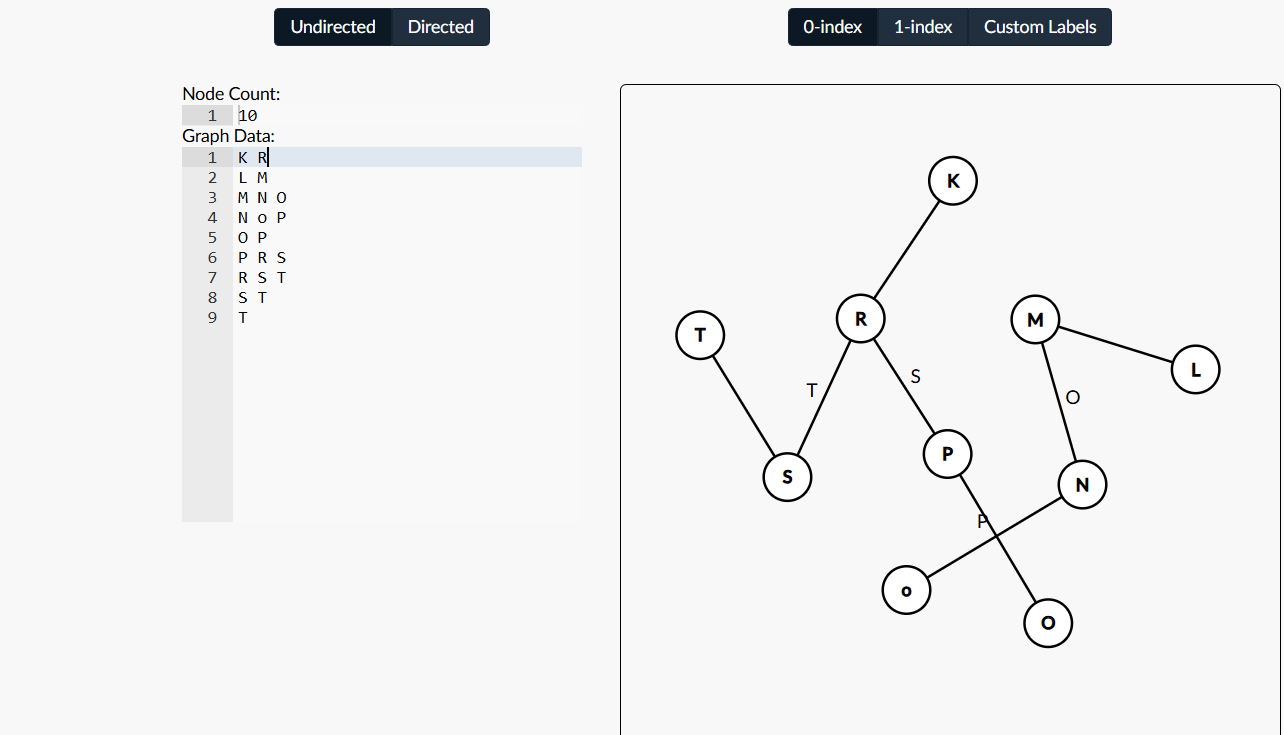

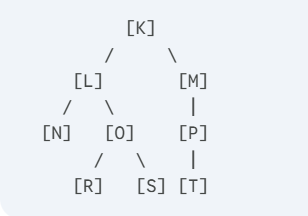

DFS

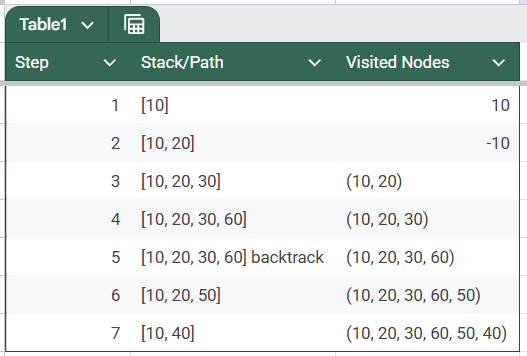

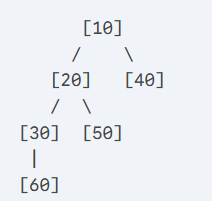

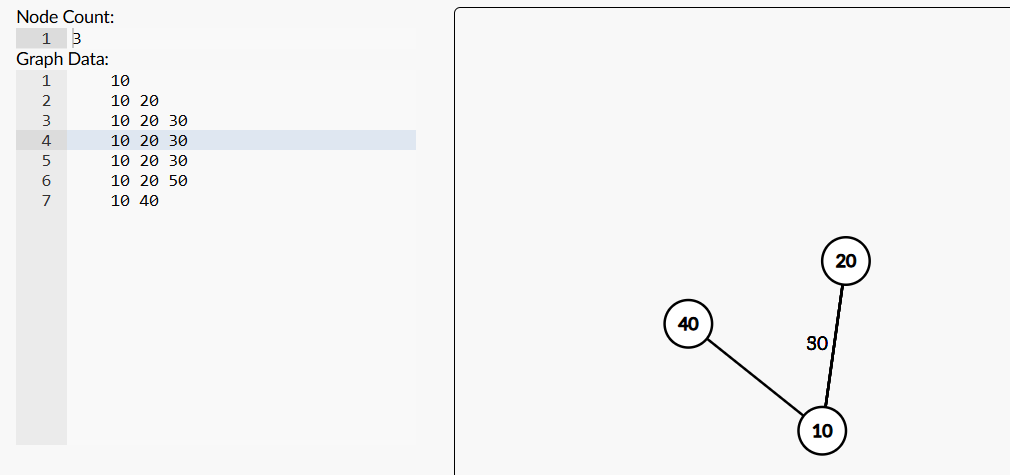

# TASK2

Processing size: 1000
Processing size: 40000
Processing size: 80000
Processing size: 200000
Processing size: 1000000

Experiment Results:
   Tree Size  BFS Time (s)  DFS Time (s)
0       1000      0.000073      0.000096
1      40000      0.007418      0.005840
2      80000      0.019813      0.017254
3     200000      0.042668      0.044549
4    1000000      0.097492      0.344877


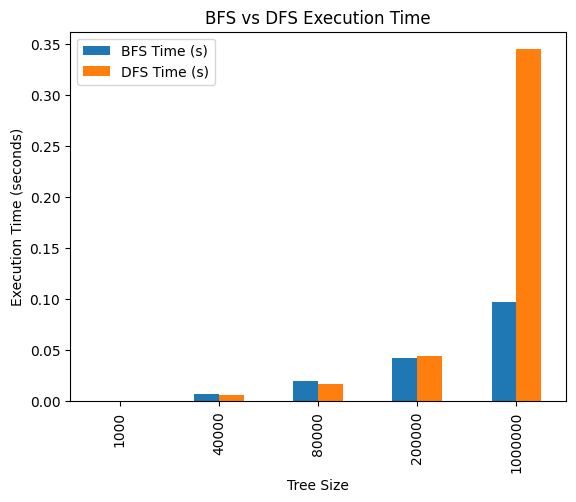

In [ ]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# Node class
class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

# Faster tree builder (balanced-like)
def build_tree(data):
    if not data:
        return None
    mid = len(data) // 2
    root = Node(data[mid])
    root.left = build_tree(data[:mid])
    root.right = build_tree(data[mid+1:])
    return root

# BFS function
def bfs(root, goal):
    start = time.perf_counter()
    queue = deque([root])
    while queue:
        node = queue.popleft()
        if node.key == goal:
            break
        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)
    return time.perf_counter() - start

# DFS function
def dfs(root, goal):
    start = time.perf_counter()
    stack = [root]
    while stack:
        node = stack.pop()
        if node.key == goal:
            break
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return time.perf_counter() - start

# Experiment parameters [cite: 171]
tree_sizes = [1000, 40000, 80000, 200000, 1000000]
bfs_times = []
dfs_times = []

for size in tree_sizes:
    print(f"Processing size: {size}")
    # Generate sorted data for a balanced tree [cite: 176]
    data = sorted(random.sample(range(1, size * 10), size))
    root = build_tree(data)

    # Selecting a goal node [cite: 177]
    goal = data[-220]

    # Measure performance [cite: 178, 179]
    bfs_times.append(bfs(root, goal))
    dfs_times.append(dfs(root, goal))

# Create DataFrame for results [cite: 185, 186, 187, 190]
results = pd.DataFrame({
    "Tree Size": tree_sizes,
    "BFS Time (s)": bfs_times,
    "DFS Time (s)": dfs_times
})

print("\nExperiment Results:")
print(results)

# Plotting the results [cite: 195, 196, 197]
results.plot(x="Tree Size", y=["BFS Time (s)", "DFS Time (s)"], kind="bar")
plt.ylabel("Execution Time (seconds)")
plt.title("BFS vs DFS Execution Time")
plt.show()

TASK#3

In [ ]:
from collections import deque

# Define the graph (cities and their connections)
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

# BFS function to find shortest path
def bfs_shortest_path(graph, start, goal):
    visited = set()
    queue = deque([[start]])  # queue stores paths

    while queue:
        path = queue.popleft()
        city = path[-1]

        if city == goal:
            return path  # shortest path found

        if city not in visited:
            visited.add(city)
            for neighbor in graph.get(city, []):
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)
    return None

# Run BFS from Islamabad to Karachi
shortest_path = bfs_shortest_path(graph, "Islamabad", "Karachi")

if shortest_path:
    print("Shortest Path (BFS):", " → ".join(shortest_path))
else:
    print("No path found.")

Shortest Path (BFS): Islamabad → Rawalpindi → Quetta → Karachi


YOUTUBE:https://youtu.be/5Grq6R1EBNE

GITHUB: